<img src="https://github.com/GJay99/Trabajos_APS/blob/master/TS0/logo_UNSAM.jpg?raw=1" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Gonzalo Jay

# Introducción
En esta tarea semanal nos centramos en el estudio del fenómeno conocido como desparramo espectral. Para ello realizamos el análisis de tres señales senoidales distintas, una que sintoniza perfectamente en la cuadrícula generada por nuestra resolución espectral y dos que difieren levemente de maneras distintas. Esto con el propósito de ver qué consecuencias traerá consigo esta desintonía en el espectro de frecuencia.

También utilizamos la herramienta conocida como identidad de Parseval para verificar la potencia unitaria y la conservación de potencia al realizar la FFT. La misma se escribe de la siguiente manera:
\begin{equation}
\sum_{n=0}^{N-1} {|x[n]|}^2 = \frac{1}{N} .\sum_{k=0}^{N-1} {|X[k]|}^2
\end{equation}
Esta fórmula puede variar dependiendo nuestra normalización u otros detalles, pero siempre parte de esta definición. Si queremos hablar de potencia podemos simplemente reescribirla como:
\begin{equation}
\frac{1}{N} .\sum_{n=0}^{N-1} {|x[n]|}^2 = \frac{1}{N^2} .\sum_{k=0}^{N-1} {|X[k]|}^2
\end{equation}

Realizamos además un último experimento mediante la técnica de zero padding, viendo cómo agregar ceros al final de nuestra señal disminuye el $\Delta_f$ de manera ficticia y cómo esto modifica al gráfico de la FFT.

# Resolución
Arrancamos agregando todas las librerías necesarias y un par de constantes útiles. En este caso esto incluye a nuestra $f_0$, la cual por enunciado va a ser $f_0=k_0 . \frac{f_s}{N} = k_0 . \Delta_f$ y $k_0=\frac{N}{4}+\{0,0.25,0.5\}$ según el caso de estudio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

/home/gonza/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
N=1000
k0=N/4
fs=1000
f0=k0*fs/N

También incluimos funciones previamente desarrolladas.

In [3]:
def mi_funcion_sen( vmax = np.sqrt(2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, nn/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)+dc
    return tt, xx

def mi_fft (xx, N, fs):
    fftxx = fft(xx)
    freq = fftfreq(N,1/fs)
    fftxx_abs = np.abs(fftxx)
    return freq, fftxx_abs

## Análisis desparramo espectral
Generamos las tres señales a estudiar, cada una con su $f_0$ correspondiente.

In [4]:
tt1, sen1=mi_funcion_sen(ff=f0)

k0=N/4+0.25
f0=k0*fs/N
tt2, sen2=mi_funcion_sen(ff=f0)

k0=N/4+0.5
f0=k0*fs/N
tt3, sen3=mi_funcion_sen(ff=f0)

Primero realizamos la señal cuyo $k_0$ coincide perfectamente con la grilla. Recordemos que:
\begin{equation}
\Delta_f = \frac{f_s}{N} = \frac{1000 Hz}{1000} = 1 Hz
\end{equation}
Por lo cual para esta resolución solo sintonizaremos correctamente frecuencias enteras, por lo cual 250 Hz lo hará. En consecuencia esperamos ver lo mismo de siempre. Un delta en 250 Hz que llegue a 0 dB y para el resto del espectro simplemente ver el piso de ruido.

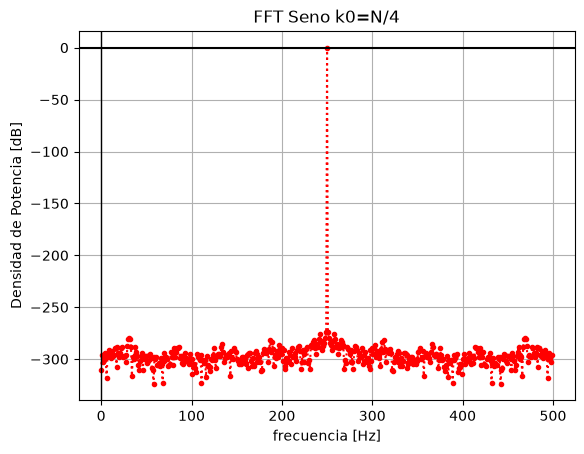

In [5]:
freq_1, fft_sen1_abs=mi_fft(sen1, N, fs)
freq_graf = freq_1[:N//2]

ref=np.max(fft_sen1_abs)
fft_sen1_abs_dB=20*np.log10(fft_sen1_abs/ref)

plt.figure(1)
plt.plot(freq_graf, fft_sen1_abs_dB[:N//2],":.", color="red")
plt.title("FFT Seno k0=N/4")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Una vez comprobamos que esto suceda podemos proseguir a analizar el resto de señales. Esto sirve para confirmar que nuestra conversión a dB está funcionando correctamente.

Continuamos viendo que pasará si agregamos a la frecuencia de N/4 0.25 Hz. Esto generará lo que llamamos desparramo espectral. Cuando la frecuencia de la señal no concuerda con las frecuencias de nuestro espectro, esto generará que la energía de la señal se desparrame a bins vecinos.

Esto se debe a que la FFT asume la periodicidad de la señal aunque nosotros le entreguemos únicamente un array finito con datos de la misma. Como mencionamos en otros trabajos, para que una señal sea periódica se debe cumplir que:
\begin{equation}
N_{periodo} = \frac{2.k.\pi}{\omega}
\end{equation}
\begin{equation}
\omega=2.\pi\frac{f_f}{f_s}=2.\pi\frac{k_0 . \frac{fs}{N}}{f_s} = 2.\pi\frac{\frac{N}{4}+0.25}{N} =2.\pi\frac{N+1}{4N}
\end{equation}
\begin{equation}
N_{periodo} = \frac{2.k.\pi}{2.\pi\frac{N+1}{4N}}=\frac{4000.k}{1001}
\end{equation}
Si $k=1001$:
\begin{equation}
N_{periodo} = \frac{4000.1001}{1001} = 4000
\end{equation}
Entonces, aunque la señal discreta sí es periódica, como nosotros solo tenemos 1000 muestras no contenemos un periodo entero de la misma, por lo cual cuando la FFT genere la periodicidad habrá un salto de discontinuidad que traerá este desparramo como consecuencia.

Existe otra forma de interpretar este fenómeno, y es mediante el análisis de las transformadas. Cuando nosotros tomamos N muestras de una senoidal es como si estuviéramos multiplicando una senoidal infinita por una ventana que va de 0 a N-1. Esta ventana al transformarla por Fourier toma la forma de una Sinc, la cual tendrá su lóbulo principal a la frecuencia donde se encuentra la \delta generada por la FFT del seno debido a que:
\begin{equation}
y_{[n]}=x_{[n]}.w_{[n]} =>Y_{[k]}=X_{[k]}*W_{[k]} = \delta_{[k-k_0]}*W_{[k]} = W_{[k-k_0]}
\end{equation}
Cuando este $k_0$ cae en nuestra grilla, se genera el típico delta con ceros que ya conocemos. Esto se debe a que el lóbulo principal coincide con la posición de la delta, mientras que tendremos ceros en el resto de puntos debido a que la Sinc tiene cruces por cero en todos los $\Delta_f$ salvo en el que coincide con k_0, es decir que aunque haya lóbulos secundarios no los apreciamos debido a la resolución espectral.

En cambio, cuando $k_0$ no coincide con la grilla, si veremos los lóbulos secundarios y ningún bin se hallará justo donde se encuentra el delta, lo que generará lo que conocemos como desparramo espectral.

-0.9189212460748498


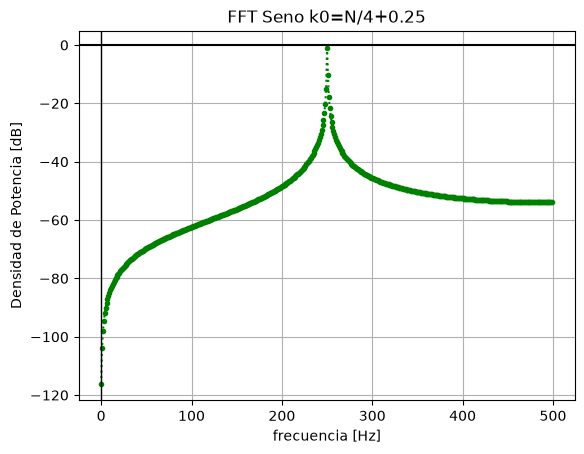

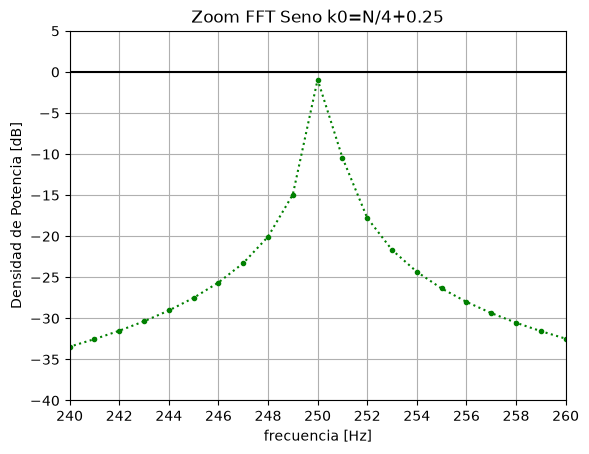

In [6]:
freq_2, fft_sen2_abs=mi_fft(sen2, N, fs)

fft_sen2_abs_dB=20*np.log10(fft_sen2_abs/ref)

plt.figure(2)
plt.plot(freq_graf, fft_sen2_abs_dB[:N//2],":.", color="green")
plt.title("FFT Seno k0=N/4+0.25")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.figure(3)
plt.plot(freq_graf, fft_sen2_abs_dB[:N//2],":.", color="green")
plt.title("Zoom FFT Seno k0=N/4+0.25")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.xlim(240, 260)
plt.ylim(-40, 5)
plt.xticks(np.arange(240,262,2))
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

print(fft_sen2_abs_dB[250])

En estas figuras podemos ver como se cumple el análisis que hicimos previamente. No vemos una única delta como nos venía pasando en los trabajos anteriores. A consecuencia de este desparramo espectral, en 250 Hz donde deberíamos tener un valor de 0 dB nos encontramos con aproximadamente -1 dB. Esto se debe a que 250.25 Hz es lo suficientemente cercano a 250 Hz para que gran parte de la energía siga cayendo sobre este bin, pero sin embargo sigue habiendo perdida de energía que podemos ver en el resto del espectro.

Esto será aún más notorio en el caso de 250.5 Hz, donde al encontrarnos justo a la mitad del espectro y en un valor de frecuencia exactamente entre dos bins, veremos como no existe un único pico si no que la mayor parte de la energía se distribuirá entre 250 Hz y 251 Hz.

250 Hz: -3.922426116100317dB
251 Hz: -3.9223403894533284dB


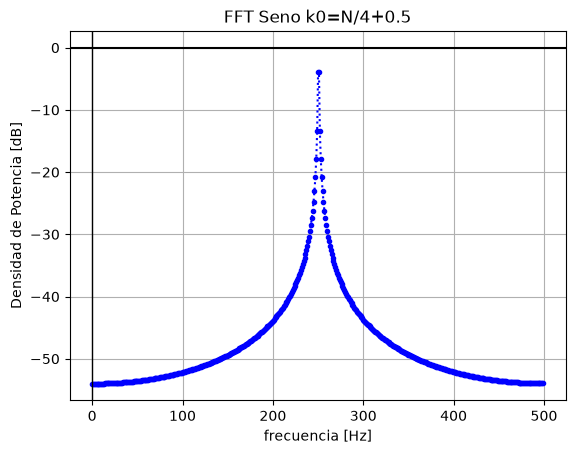

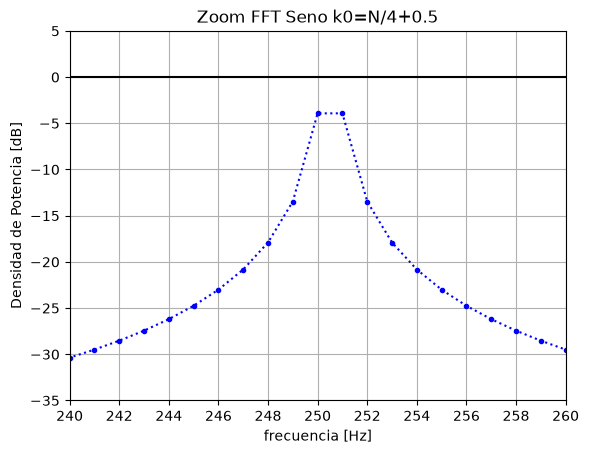

In [7]:
freq_3, fft_sen3_abs=mi_fft(sen3, N, fs)

fft_sen3_abs_dB=20*np.log10(fft_sen3_abs/ref)

plt.figure(4)
plt.plot(freq_graf, fft_sen3_abs_dB[:N//2],":.", color="blue")
plt.title("FFT Seno k0=N/4+0.5")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.figure(5)
plt.plot(freq_graf, fft_sen3_abs_dB[:N//2],":.", color="blue")
plt.title("Zoom FFT Seno k0=N/4+0.5")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.xlim(240, 260)
plt.ylim(-35, 5)
plt.xticks(np.arange(240,262,2))
print(f"250 Hz: {fft_sen3_abs_dB[250]}dB")
print(f"251 Hz: {fft_sen3_abs_dB[251]}dB")

Se puede apreciar como el desparramo tiene una forma casi totalmente simétrica, donde probablemente el lado derecho este unos decimales por arriba pero en una magnitud casi despreciable. De hecho, en los print del código podemos ver como en 250 Hz y 251 Hz tenemos el pico de esta FFT donde ambas se dan en aproximadamente -3.92 dB. Nuevamente esta simetria se da porque justamente nuestra frecuencia se encuentra en el centro de la grilla, permitiendo que el desparramo se produzca de igual manera para ambos lados.

## Análisis identidad de Parseval

Para comprobar si este desparramo espectral esta generando energía o simplemente la está dividiendo en más bins podemos utilizar la identidad de Parseval. Esta identidad se basa en la conservación de la energía, vinculando la sumatoria del modulo cuadrado de la señal original con la misma sumatoria pero de la señal transformada. Si efectivamente se cumple la conservación, estas sumatorios deberían dar igual.

In [8]:
Pot_sen1=np.sum(sen1**2)/N
Pot_fft_sen1=np.sum(fft_sen1_abs**2)/N**2
print(f"Potencia señal original: {Pot_sen1}W. Potencia de la señal transformada: {Pot_fft_sen1}W")

Pot_sen2=np.sum(sen2**2)/N
Pot_fft_sen2=np.sum(fft_sen2_abs**2)/N**2
print(f"Potencia señal original: {Pot_sen2}W. Potencia de la señal transformada: {Pot_fft_sen2}W")

Pot_sen3=np.sum(sen3**2)/N
Pot_fft_sen3=np.sum(fft_sen3_abs**2)/N**2
print(f"Potencia señal original: {Pot_sen3}W. Potencia de la señal transformada: {Pot_fft_sen3}W")

Potencia señal original: 1.0000000000000002W. Potencia de la señal transformada: 1.0000000000000002W
Potencia señal original: 0.9989999999999996W. Potencia de la señal transformada: 0.9989999999999994W
Potencia señal original: 1.0000000000000004W. Potencia de la señal transformada: 1.0000000000000004W


Si bien existe una pequeña diferencia en algunos casos, esta se da en el último decimal por lo cual podemos asumir que se debe a un error numérico simplemente. Esto nos demuestra que cuando se genera desparramo espectral no estamos perdiendo potencia. Simplemente, la potencia que antes veíamos acumulada en un delta se esparce a lo largo de todo el espectro.

## Análisis FFT con zero padding

Cómo segundo marco de análisis se nos encomendó ver que sucedía si utilizábamos el mismo vector de datos, tomado de las senoides del ejercicio anterior, pero al final agregamos un vector de ceros con tamaño igual a nueve veces N. Para hacer esto, simplemente generamos un vector de ceros con tamaño 9.N y lo concatenamos a los vectores de las señales.

In [9]:
ceros=np.zeros(9*N)
sen1_0=np.concatenate((sen1,ceros))
sen2_0=np.concatenate((sen2,ceros))
sen3_0=np.concatenate((sen3,ceros))

Como mencionamos en la introducción, lo que esto va a logar es un aumento artificial de nuestra resolución espectral, pues:
\begin{equation}
\Delta_f = \frac{f_s}{N+9N} = \frac{1000 Hz}{10000} = 0.1 Hz
\end{equation}
Es importante aclarar que esta resolución espectral no es real, ya que la información real sigue siendo la misma, simplemente permite aumentar el muestreo de la FFT. Lo que va a traer consigo, al menos, dos consecuencias predecibles. La primera sería que ahora si seremos capaz de apreciar los picos en, por ejemplo, 250.5 Hz ya que es un valor múltiplo de nuestro $\Delta_f$, lo cuál nos permitirá apreciar mejor ciertos picos. Pero, también generará que casos donde antes podíamos ver el delta casi ideal como con 250 Hz ahora veamos un mayor ruido a causa de que tendremos una mayor visualización de la Sinc generada por la ventana implícita. Esto debido a que nuestro $\Delta_f$ no será justamente los cruces por cero de la Sinc, si no que también pasará por puntos intermedios.

[0.]


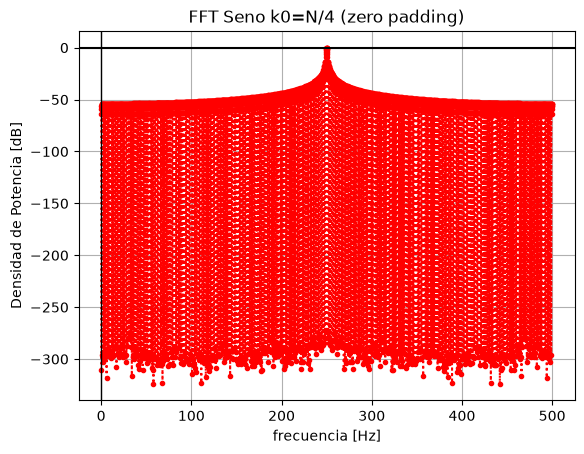

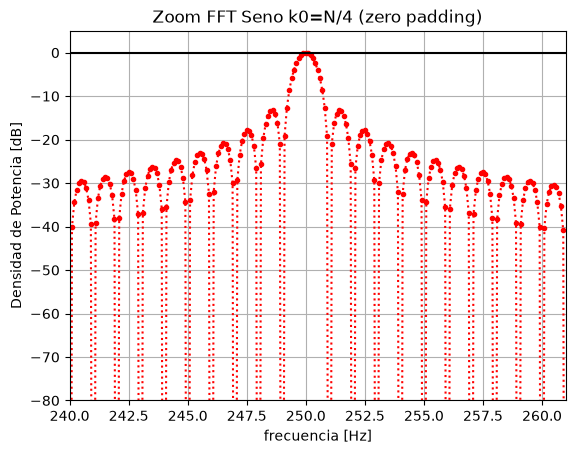

In [10]:
freq_1, fft_sen1_0_abs=mi_fft(sen1_0, 10*N, fs)
freq_graf = freq_1[:10*N//2]

ref=np.max(fft_sen1_0_abs)
fft_sen1_0_abs_dB=20*np.log10(fft_sen1_0_abs/ref)

plt.figure(6)
plt.plot(freq_graf, fft_sen1_0_abs_dB[:10*N//2], ":.", color="red")
plt.title("FFT Seno k0=N/4 (zero padding)")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.figure(7)
plt.plot(freq_graf, fft_sen1_0_abs_dB[:10*N//2], ":.", color="red")
plt.title("Zoom FFT Seno k0=N/4 (zero padding)")
plt.xlim(240, 261)
plt.ylim(-80, 5)
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
print(fft_sen1_0_abs_dB[freq_1==250])

Podemos apreciar como justamente vemos el lóbulo principal y los lóbulos secundarios de la Sinc. Sin embargo, esto no es el mismo fenómeno de desparramo espectral, porque justamente el pico del lóbulo principal en 250Hz concuerda con los 0 dB que esperábamos ver. Este es otro fenómeno sin relación dado por el zero padding. En sí, estos lóbulos ya se encontraban en el espetro original, pero con N=1000 los bins coincidían con los cruces por cero de la transformada de la ventana explícita. Es decir, que el zero padding no genera estos puntos ni modifica el espectro, simplemente permite muestrearlo con más puntos intermedios.

Pasando a analizar el caso de f=250.25 Hz, la diferencia será que en este caso se sumarán ambos efectos. Como 250.25 Hz sigue sin caer en nuestra grilla de resolución espectral, seguirá habiendo un desparramo espectral. Sin embargo, al disminuir el espaciamiento entre los puntos de la FFT podemos muestrear con mayor detalle la forma de la Sinc, encontrando frecuencias más cercanas al máximo de la función, en este caso 250.2 Hz y 250.3 Hz. Una última diferencia con la figura de la FFT para esta misma frecuencia pero sin zero padding, es que en este caso si veremos la simetría aparente.

250.2 Hz: [-0.04436728]dB
250.3 Hz: [-0.04436729]dB


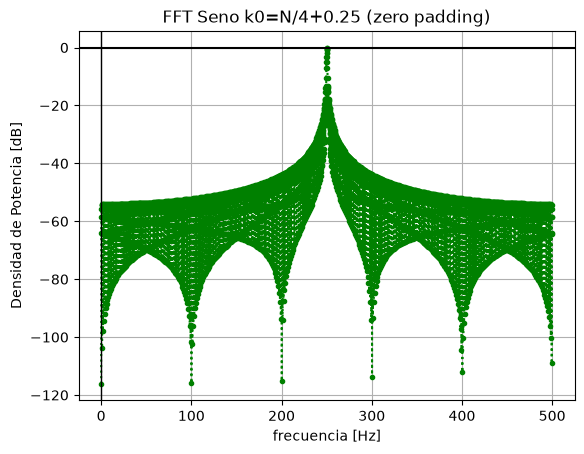

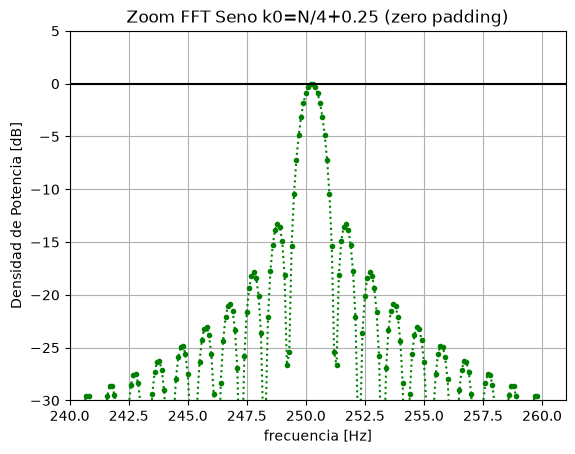

In [11]:
freq_2, fft_sen2_0_abs=mi_fft(sen2_0, 10*N, fs)

fft_sen2_0_abs_dB=20*np.log10(fft_sen2_0_abs/ref)

plt.figure(8)
plt.plot(freq_graf, fft_sen2_0_abs_dB[:10*N//2],":.", color="green")
plt.title("FFT Seno k0=N/4+0.25 (zero padding)")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.figure(9)
plt.plot(freq_graf, fft_sen2_0_abs_dB[:10*N//2],":.", color="green")
plt.title("Zoom FFT Seno k0=N/4+0.25 (zero padding)")
plt.xlim(240, 261)
plt.ylim(-30, 5)
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

print(f"250.2 Hz: {fft_sen2_0_abs_dB[np.round(freq_2,1)==250.2]}dB")
print(f"250.3 Hz: {fft_sen2_0_abs_dB[np.round(freq_2,1)==250.3]}dB")

Justamente ahora la estimación es mejor, ya que ambos picos se encuentran en aproximadamente -0.04 dB, pero sigue sin haber un punto perfectamente localizado en 0 dB.

Por último llegamos al caso de 250.5 Hz, donde deberíamos ser capaces de ver el pico de 0 dB, gracias a que ahora la frecuencia cae en uno de los bins.

[1.92865493e-15]


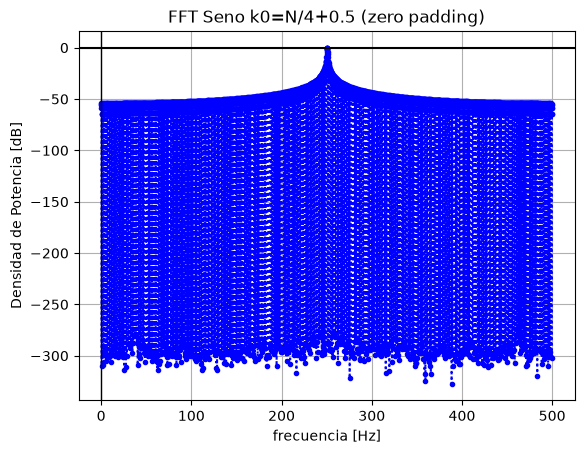

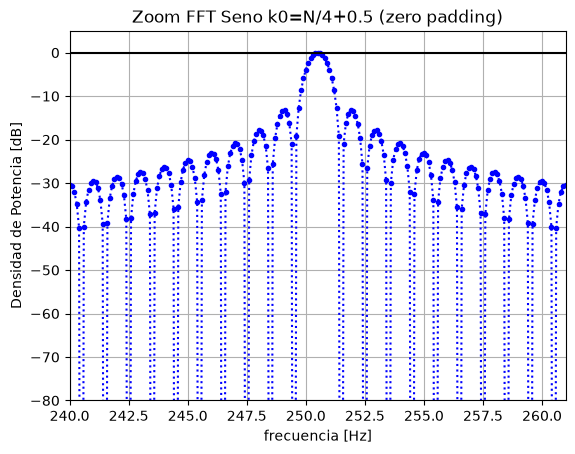

In [12]:
freq_3, fft_sen3_0_abs=mi_fft(sen3_0, 10*N, fs)

fft_sen3_0_abs_dB=20*np.log10(fft_sen3_0_abs/ref)

plt.figure(10)
plt.plot(freq_graf, fft_sen3_0_abs_dB[:10*N//2], ":.", color="blue")
plt.title("FFT Seno k0=N/4+0.5 (zero padding)")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.figure(11)
plt.plot(freq_graf, fft_sen3_0_abs_dB[:10*N//2], ":.", color="blue")
plt.title("Zoom FFT Seno k0=N/4+0.5 (zero padding)")
plt.xlim(240, 261)
plt.ylim(-80, 5)
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

print(fft_sen3_0_abs_dB[freq_3==250.5])

Efectivamente, podemos observar correctamente el máximo del lóbulo principal en la frecuencia de nuestra señal, en aproximadamente 0 dB. No se debe confundir esto con evitar el desparramo espectral, simplemente el agregar mayor cantidad de puntos somos capaces de ver el pico de la Sinc.

Esto nos hace pensar que el zero padding puede sernos de utilidad si queremos ver donde se encuentra la frecuencia predominante de la señal o visualizar con mayor detalle el espectro. Sin embargo, no aporta información nueva ya que la resolución real es la que genera esto, y esa depende solo de los puntos con información de la señal. Es por esto que para señales que ya de por si se aprecia el $\delta$ con claridad, no se piensa como primer opción aplicar esta técnica.

## Análisis Parseval con zero padding

Por último, un análisis interesante sería ver si estos nuevos puntos que vemos de la Sinc o si el zero padding agrega energía a la señal. Para esto, nuevamente, nos apoyamos en la identidad de Parseval solo que agregando un detalle. No usaremos $N^2$, si no que  tendremos que dividir tanto por la totalidad de los puntos, como de los puntos distintos de cero que tiene el vector.

In [13]:
Pot_sen1=np.sum(sen1**2)/N
Pot_fft_sen1=np.sum(fft_sen1_0_abs**2)/N * (1/(10*N))
print(f"Potencia señal original: {Pot_sen1}W. Potencia de la señal transformada: {Pot_fft_sen1}W")

Pot_sen2=np.sum(sen2**2)/N
Pot_fft_sen2=np.sum(fft_sen2_0_abs**2)/N * (1/(10*N))
print(f"Potencia señal original: {Pot_sen2}W. Potencia de la señal transformada: {Pot_fft_sen2}W")

Pot_sen3=np.sum(sen3**2)/N
Pot_fft_sen3=np.sum(fft_sen3_0_abs**2)/N * (1/(10*N))
print(f"Potencia señal original: {Pot_sen3}W. Potencia de la señal transformada: {Pot_fft_sen3}W")

Potencia señal original: 1.0000000000000002W. Potencia de la señal transformada: 1.0W
Potencia señal original: 0.9989999999999996W. Potencia de la señal transformada: 0.9989999999999999W
Potencia señal original: 1.0000000000000004W. Potencia de la señal transformada: 1.0000000000000007W


Como la potencia es exactamente igual, únicamente con cambios en el último decimal que nuevamente culparemos a un error numérico, podemos decir que el zero padding no quita ni agrega energía de nuestra señal original.

# Conclusión
A lo largo de este informe pudimos discutir acerca de las consecuencias de analizar mediante la FFT señales cuya frecuencia no caigan exactamente sobre la cuadrícula de nuestra resolución espectral, debida a la frecuencia de muestreo y la cantidad de puntos tomados.

Si se realiza esta FFT sin zero padding, se verá el efecto conocido como desparramo espectral, en el cuál la energía correspondiente a la señal se desparrama al resto de componentes frecuenciales. Este desparramo tendrá comportamientos distintos según, entre otros factores, a que altura del espectro se encuentre y que tanta distancia haya entre esta frecuencia y una que si corresponda a la grilla.

Por otro lado, existe la posibilidad de analizar la señal mediante zero padding. Esta técnica no agrega ninguna información adicional a la señal, ni aumenta la resolución espectral real, simplemente disminuye la distancia entre puntos en los que se evalúa la transformada, mostrando más detalles entre frecuencias. Esto puede ser de utilidad, por ejemplo, cuando queremos estimar con mayor precisión la frecuencia a la cuál se encuentra el lóbulo principal de la Sinc.

Es importante destacar que ninguno de los dos métodos implica una pérdida de la energía ni la potencia de la señal, tampoco un aumento. Apoyándonos en la identidad de Parseval podemos medir la potencia de la señal original y de la transformada. Como resultado, observamos que si bien la energía se distribuye a lo largo del espectro, la misma se conserva, y sumando todas las componentes obtendremos lo mismo que esperaríamos de la señal sin desparramo o sin los ceros de más.